# The machines

Every board a node; a humanoid, a quad, a fixed wing, an e-bike over them; programs a model writes, streamed live behind a failsafe.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 The nodes

`Nodes.discover` loads each installed board family - here `coaxial.node` - which finds its boards on every bus; then the robot's other boards, a battery pack and a head camera. Each is a node named where it sits, asked what it offers first.

In [3]:
from machine.nodes import Nodes

nodes = Nodes.discover(port=PORT, simulated=SIMULATED)
kinds = sorted({n.type for n in nodes})
print('%d nodes: %s' % (len(nodes), ', '.join('%d %s' % (len(nodes.of_type(k)), k) for k in kinds)))
print(Nodes([nodes['battery'], nodes['head_camera']]).card())
offered = len(nodes.capabilities())
print(offered, 'channels in all')

22 nodes: 20 bldc_inverter, 1 bms, 1 camera
battery: bms simulated_bms at torso, simulated unit 0
  in  pack.amps A, pack.cell_min V, pack.contactor 0/1, pack.soc 1, pack.temp C, pack.volts V
  out pack.contactor 0/1 0..1
head_camera: camera simulated_camera at head, simulated unit 0
  in  vision.target.seen 0/1, vision.target.x 1, vision.target.y 1
1870 channels in all


## 3 A humanoid, and what a model is told

`Machine(nodes, type='humanoid')`: a joint on every node that offers one, the pack and the camera read beside them; `Machine.discover('humanoid', port=PORT)` is both steps. `prompt()` is the grammar, the joints, what can be read, the routines.

In [4]:
from machine import Machine

humanoid = Machine(nodes, type='humanoid')
told = humanoid.prompt()
print(told)
print('%d characters, about %d tokens' % (len(told), len(told) / 4))

One step a line: seconds, then name=value. # starts a comment.
  knee=40            set a target            n+=1         add to a counter
  knee.deg.H=38      end the step once reached (.L: once below)
  label=up           name the line           then=up else=down   go there when a level
  goto=up times=3    after the line, back 3 times             ended the step / when time did
  group=init         runs first; group=cleanup runs last, always
  run=walk times=4 stride=25   a routine below, its params by name, times over
0 seconds: a decision, no time passes. A jump to stop ends the program.

This machine (humanoid):
set  pelvis, waist, neck, head, left_shoulder, left_elbow, left_wrist, left_gripper, left_hip, left_knee, left_ankle, left_foot, right_shoulder, right_elbow, right_wrist, right_gripper, right_hip, right_knee, right_ankle, right_foot deg -90..90  (read back as <name>.deg)
set  battery.contactor 0..1
read battery.pack.amps, battery.pack.cell_min, battery.pack.contactor, batte

## 4 A program, as a model answers

Routines by name, and a search: the head turns 10 deg at a time until the camera sees the target, then 2 deg at a time until it is centred - a closed loop, as data.

In [5]:
PROGRAM = """
# squat twice, wave three times, then find the target and centre it
0 run=squat times=2
0 run=wave times=3
0 run=rest
0.3 label=scan head+=10 head_camera.vision.target.seen.H=1 then=aim
0 goto=scan times=6
0.2 label=aim head+=2 head_camera.vision.target.x.L=0.05 then=found
0 goto=aim times=20
0 label=found
0 run=stand
"""
out = humanoid.run(PROGRAM)
print(out.summary('head.deg', 'head_camera.vision.target.x', 'battery.pack.volts'))

done after 12.12 s, 35 steps
  row 0 1.16 s time
  row 1 1.16 s time
  row 2 1.16 s time
  row 3 1.16 s time
  row 4 0.60 s time
  row 5 0.59 s time
  row 6 0.56 s time
  row 7 0.56 s time
  row 8 0.56 s time
  row 9 0.56 s time
  ...
  row 16 1.00 s time
  end: head.deg 39.99, head_camera.vision.target.x 0.0003255, battery.pack.volts 49.32


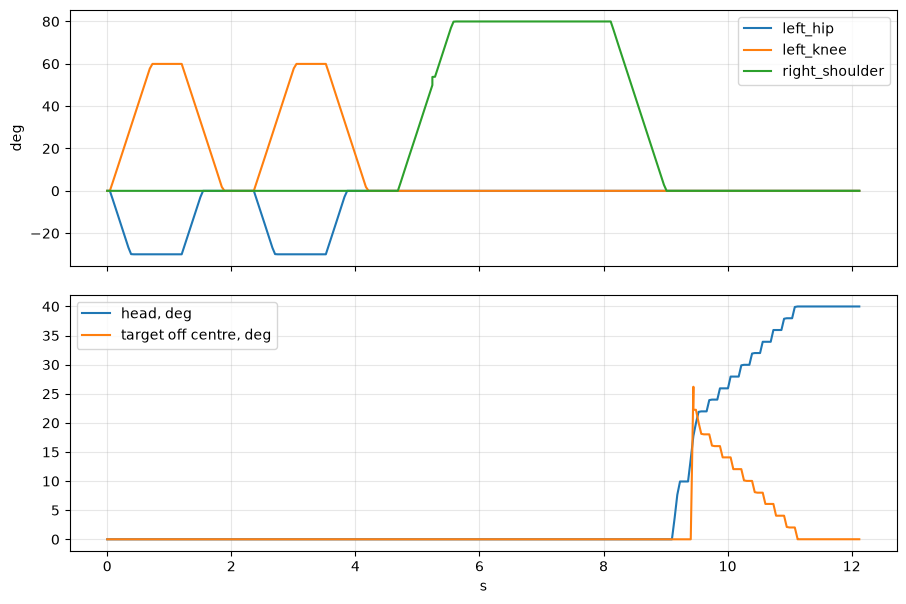

In [6]:
from coaxial.draw.figures import figure, show

t = [r['t'] for r in out.rows]
fig, (legs, head) = figure(rows=2, sharex=True)
for joint in ('left_hip', 'left_knee', 'right_shoulder'):
    legs.plot(t, [r[joint + '.deg'] for r in out.rows], label=joint)
legs.set_ylabel('deg')
legs.legend(loc='upper right')
head.plot(t, [r['head.deg'] for r in out.rows], label='head, deg')
head.plot(t, [30 * r['head_camera.vision.target.x'] for r in out.rows], label='target off centre, deg')
head.set_xlabel('s')
head.legend(loc='upper left')
show(fig)

## 5 When the model is wrong

Checked before anything arms, one line back: the routine meant, a parameter it does not take, a target out of range, a value that is not a number.

In [7]:
from machine.errors import MachineError

refusals = []
for wrong in ('0 run=wlak', '0 run=walk strides=3', '0 run=squat knee=120', '0.5 head=4O'):
    try:
        humanoid.run(wrong)
    except MachineError as exc:
        refusals.append(str(exc).splitlines()[-1])
        print('%-22s -> %s' % (wrong, refusals[-1]))

0 run=wlak             -> line 0: no routine wlak - did you mean walk? - there are stand, squat, walk, wave, look, rest
0 run=walk strides=3   -> line 0: walk takes stride, lift, period, not strides
0 run=squat knee=120   -> row 0: right_knee=120 is outside -90..90
0.5 head=4O            -> row 0: head=4O is not a number


## 6 Other machines, the same nodes

A type is data: the actuators it wants by kind, and its routines. The quad's rotors are speed loops (rpm), the fixed wing's surfaces narrow joints, the e-bike's assist a current.

In [8]:
RUNS = {'quad': '0 run=take_off\n0 run=hover seconds=1\n0 run=yaw\n0 run=land',
        'fixed_wing': '0 run=take_off\n0 run=bank deg=-15\n0 run=land',
        'ebike': '0 run=assist amps=3 seconds=2\n0 run=coast'}
others = {}
for kind, program in RUNS.items():
    machine = Machine(nodes, type=kind)
    print(machine.prompt().splitlines()[-1])
    others[kind] = machine.run(program)
    print('  %s' % others[kind].summary().splitlines()[0])

run  take_off(seconds=1 rpm=3500), hover(seconds=2 rpm=3000), yaw(seconds=1 high=3200 low=2800), pitch(seconds=1 front=2800 rear=3200), land(seconds=1.5 rpm=1500)


  done after 6.90 s, 6 steps
run  take_off(seconds=1.5 rpm=5000 pitch=10), cruise(seconds=2 rpm=4000), bank(seconds=1.5 deg=15), land(seconds=2 rpm=2000 pitch=5)


  done after 9.93 s, 6 steps
run  assist(seconds=5 amps=2.5), coast(seconds=1)


  done after 2.97 s, 2 steps


## 7 Live: a stream, a buffer, a failsafe

`Live` plays chunks as they arrive, from a buffer of at most `horizon` seconds; silence past `timeout` plays the failsafe. Here the model streams, stumbles once, then goes quiet.

In [9]:
import time
from machine.live import Live

live = Live(humanoid, failsafe='0 run=stand seconds=0.8', timeout=1.0, horizon=2.0).start()
t0 = time.monotonic()
for chunk in ('0.5 left_knee=20 right_knee=20', '0 run=walk stride=15', '0.5 head=4O',
              '0 run=walk stride=15', '0 run=walk stride=15'):
    said = live.send(chunk)
    print('%4.1f s  %-30s %s' % (time.monotonic() - t0, chunk, said or 'queued'))
    time.sleep(0.4)
time.sleep(4.0)
streamed = live.stop()
print(streamed)

 0.0 s  0.5 left_knee=20 right_knee=20 queued


 0.4 s  0 run=walk stride=15           queued


 0.8 s  0.5 head=4O                    refused: row 0: head=4O is not a number


 1.2 s  0 run=walk stride=15           queued


 1.6 s  0 run=walk stride=15           refused: 1.60 s buffered, the horizon 2.00 s - send when it drains


{'status': 'stopped', 'reason': 'nothing sent for 1.00 s', 'buffered': 0, 'queued': 0, 'played': 3, 'wait_max': 1.0685194000034244, 'wait_mean': 0.4181892666698938, 'errors': ['row 0: head=4O is not a number']}


## 8 Through the board chat

The `program` tool is what the local model calls: `op=card`, then `op=run` with its answer, on any type.

In [10]:
from coaxial.simulated.board import SimulatedSession
from coaxial_mcp.tools import program

session = SimulatedSession(port='AX')
print(program(session, op='run', machine='quad', text='0 run=take_off\n0 run=land'))
session.nodes.close()
nodes.close()

done after 4.92 s, 4 steps
  row 0 0.98 s time
  row 1 0.98 s time
  row 2 1.48 s time
  row 3 1.47 s time


In [11]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 9 Results

In [12]:
print('1. nodes      %d; %d channels offered' % (len(nodes), offered))
print('2. the prompt %d characters for %d joints and their routines' % (len(told), len(humanoid.actuators)))
print('3. the run    %s, %d steps; the target %.2f of the half field off centre'
      % (out.status, len(out.steps), out.rows[-1]['head_camera.vision.target.x']))
print('4. refused    %d of 4, each in a line' % len(refusals))
print('5. others     %s' % ', '.join('%s %s' % (k, o.status) for k, o in others.items()))
print('6. live       %s after %s; %d chunks played, worst wait %.2f s'
      % (streamed['status'], streamed['reason'], streamed['played'], streamed['wait_max']))

1. nodes      22; 1870 channels offered
2. the prompt 1320 characters for 20 joints and their routines
3. the run    done, 35 steps; the target 0.00 of the half field off centre
4. refused    4 of 4, each in a line
5. others     quad done, fixed_wing done, ebike done
6. live       stopped after nothing sent for 1.00 s; 3 chunks played, worst wait 1.07 s


- The model writes lines and names routines, not code: the sequencer runs, the loop holds.
- A wrong line costs one line back; silence costs the failsafe; a limit trips.

**Bench.** Discover through the broker; arming empty (the STO chain released); every joint commissioned and its span set; the failsafe a routine that is safe from anywhere.

## References

* `host/machine/nodes.py` - `Node`, `Nodes`, `FAMILIES`: boards as IO nodes, capabilities first
* `host/machine/machine.py` - `Machine`: actuators over nodes; `discover`, `prompt`, `run`
* `host/coaxial/node.py` - the Coaxial63100 family: its node, joint, surface, rotor, torque
* `host/machine/routines.py` - the types and their routines
* `host/machine/live.py` - `Live`: chunks, a buffer, a watchdog, a failsafe
* `host/machine/sequencer.py` - lines or tables; `check`, `summary`, `GRAMMAR`
* `host/coaxial_mcp/tools.py` - `program`: the board-chat tool